# Hybrid Underwater Image Enhancement
### CNN + Blind Denoising Pipeline  (v3 – stable)

**Objectives:**
1. Hybrid model: DnCNN-style Blind Denoiser + Residual CNN Enhancer
2. Color correction, contrast enhancement, structural detail preservation
3. Evaluation on UIEB benchmark: PSNR, SSIM, MSE, UIQM, UCIQE

In [18]:
!pip install -q scikit-image torch torchvision

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.color import rgb2lab, rgb2hsv
from skimage.filters import sobel
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import os, warnings
warnings.filterwarnings('ignore')  # suppress skimage casting warnings

In [20]:
# ── Config ─────────────────────────────────────────────────────────────────────
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE  = 256
LR        = 2e-4        # Lower LR → more stable than 1e-3 with LAB loss
EPOCHS    = 200
SSIM_W    = 0.5         # Weight for SSIM loss term
COLOR_W   = 0.05        # FIX: small weight – LAB values are ~100x larger than [0,1] pixels
GRAD_CLIP = 0.5         # FIX: tighter clip to catch early instability
BATCH     = 4

RAW_DIR = r'/kaggle/input/datasets/paulettegudapati/underwater-image-enhancement/underwater-image-enhancement/raw-890/raw-890'
REF_DIR = r'/kaggle/input/datasets/paulettegudapati/underwater-image-enhancement/underwater-image-enhancement/reference-890/reference-890'

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
print(f'Device: {DEVICE}')

Device: cuda


In [21]:
# ── Dataset ────────────────────────────────────────────────────────────────────
class UnderwaterDataset(Dataset):
    def __init__(self, raw_dir, ref_dir, transform=None):
        self.raw_dir   = raw_dir
        self.ref_dir   = ref_dir
        self.transform = transform
        # Only keep files present in BOTH directories
        self.files = sorted(set(os.listdir(raw_dir)) & set(os.listdir(ref_dir)))
        print(f'Dataset: {len(self.files)} matched pairs')

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        raw = Image.open(os.path.join(self.raw_dir, self.files[idx])).convert('RGB')
        ref = Image.open(os.path.join(self.ref_dir, self.files[idx])).convert('RGB')
        if self.transform:
            raw = self.transform(raw)
            ref = self.transform(ref)
        return raw, ref

In [22]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# OBJECTIVE 1 – HYBRID MODEL
# Stage 1: BlindDenoiser  (DnCNN-style, residual noise subtraction)
# Stage 2: ColorEnhancer  (ResBlocks + Channel Attention + global skip)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

class BlindDenoiser(nn.Module):
    """
    DnCNN-style blind denoiser.
    Learns residual noise map; denoised = clamp(input - noise, 0, 1).
    Output clamped to [0,1] to prevent negative values reaching LAB conversion.
    """
    def __init__(self, depth=8, ch=64):
        super().__init__()
        layers = [nn.Conv2d(3, ch, 3, padding=1), nn.ReLU(inplace=True)]
        for _ in range(depth - 2):
            layers += [
                nn.Conv2d(ch, ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(ch),
                nn.ReLU(inplace=True),
            ]
        layers.append(nn.Conv2d(ch, 3, 3, padding=1))
        self.dncnn = nn.Sequential(*layers)

    def forward(self, x):
        noise = self.dncnn(x)
        # FIX: clamp output so downstream LAB conversion never sees negatives
        return torch.clamp(x - noise, 0.0, 1.0)


class ResBlock(nn.Module):
    """Residual block with BN for structural detail preservation."""
    def __init__(self, ch=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch),
        )
    def forward(self, x):
        return F.relu(x + self.block(x), inplace=True)


class ColorEnhancer(nn.Module):
    """
    CNN Enhancer (Objective 2):
      - ResBlocks preserve structural details
      - Squeeze-and-Excitation channel attention corrects per-channel color
      - Global residual skip prevents over-smoothing
      - Sigmoid + clamp ensures output stays in [0, 1]
    """
    def __init__(self, n_res=6, ch=64):
        super().__init__()
        self.head = nn.Sequential(
            nn.Conv2d(3, ch, 3, padding=1), nn.ReLU(inplace=True)
        )
        self.body = nn.Sequential(*[ResBlock(ch) for _ in range(n_res)])
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(ch, ch // 4), nn.ReLU(inplace=True),
            nn.Linear(ch // 4, ch), nn.Sigmoid(),
        )
        self.tail = nn.Conv2d(ch, 3, 3, padding=1)

    def forward(self, x):
        feat = self.body(self.head(x))
        feat = feat * self.se(feat).view(feat.size(0), feat.size(1), 1, 1)
        # FIX: clamp instead of Sigmoid-in-Sequential; keeps gradient cleaner
        return torch.clamp(self.tail(feat) + x, 0.0, 1.0)

In [23]:
# ── Differentiable SSIM Loss ───────────────────────────────────────────────────
def gaussian_kernel(size=11, sigma=1.5):
    c = torch.arange(size, dtype=torch.float32) - size // 2
    g = torch.exp(-(c**2) / (2*sigma**2))
    g = torch.outer(g, g)
    return g / g.sum()

def ssim_loss(pred, target, ksize=11, sigma=1.5):
    C1, C2 = 0.01**2, 0.03**2
    _, C, _, _ = pred.shape
    k = gaussian_kernel(ksize, sigma).to(pred.device).expand(C, 1, ksize, ksize)
    pad = ksize // 2
    def W(x): return F.conv2d(x, k, padding=pad, groups=C)
    mp, mt = W(pred), W(target)
    sp  = W(pred*pred)   - mp*mp
    st  = W(target*target) - mt*mt
    spt = W(pred*target) - mp*mt
    num = (2*mp*mt + C1) * (2*spt + C2)
    den = (mp*mp + mt*mt + C1) * (sp + st + C2)
    return 1.0 - (num / (den + 1e-8)).mean()


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# OBJECTIVE 2 – PERCEPTUAL COLOR LOSS (NaN-safe)
#
# Key fixes vs v2:
#  1. Hard clamp to [1e-6, 1.0] before the power op → no negative base
#  2. Normalise LAB output to roughly [0,1] before MSE
#     (L/100, a/128+0.5, b/128+0.5) → scale comparable to pixel MSE
#  3. COLOR_W = 0.05 not 0.3 → loss terms stay balanced
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def rgb_to_lab_normalised(img):
    """
    Differentiable RGB→Lab conversion, output normalised to ~[0,1].
    img : (B, 3, H, W) tensor, values in [0, 1].
    """
    # FIX 1: clamp strictly positive before power
    img = torch.clamp(img, 1e-6, 1.0)
    # sRGB → linear
    linear = torch.where(
        img > 0.04045,
        ((img + 0.055) / 1.055).clamp(min=1e-8) ** 2.4,
        img / 12.92
    )
    # linear RGB → XYZ D65
    M = torch.tensor([[0.4124, 0.3576, 0.1805],
                       [0.2126, 0.7152, 0.0722],
                       [0.0193, 0.1192, 0.9505]],
                      device=img.device, dtype=img.dtype)
    B, C, H, W = linear.shape
    xyz = (linear.permute(0,2,3,1).reshape(-1,3) @ M.T).reshape(B,H,W,3).permute(0,3,1,2)
    # Normalise by D65 white point
    wp = torch.tensor([0.9505, 1.0000, 1.0890], device=img.device).view(1,3,1,1)
    xyz = torch.clamp(xyz / wp, min=1e-8)
    # XYZ → f(t)
    delta = 6.0 / 29.0
    ft = torch.where(xyz > delta**3,
                     xyz.clamp(min=1e-8) ** (1.0/3.0),
                     xyz / (3 * delta**2) + 4.0/29.0)
    L = 116.0 * ft[:,1] - 16.0          # [0, 100]
    a = 500.0 * (ft[:,0] - ft[:,1])     # ~[-128, 128]
    b = 200.0 * (ft[:,1] - ft[:,2])     # ~[-128, 128]
    lab = torch.stack([L, a, b], dim=1)

    # FIX 2: normalise to [0,1]-comparable range
    norm = torch.tensor([100.0, 256.0, 256.0], device=img.device).view(1,3,1,1)
    return lab / norm

def color_loss(pred, target):
    """MSE in normalised LAB space – penalises color cast and contrast error."""
    return F.mse_loss(rgb_to_lab_normalised(pred), rgb_to_lab_normalised(target))


# ── Combined loss ──────────────────────────────────────────────────────────────
mse_fn = nn.MSELoss()

def total_loss(pred, target):
    l_mse   = mse_fn(pred, target)
    l_ssim  = ssim_loss(pred, target)
    l_color = color_loss(pred, target)
    loss = l_mse + SSIM_W * l_ssim + COLOR_W * l_color
    # FIX 3: nan guard – skip NaN batches rather than propagate
    if not torch.isfinite(loss):
        return l_mse   # fallback to plain MSE
    return loss

In [24]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# OBJECTIVE 3 – METRICS: PSNR, SSIM, MSE, UIQM, UCIQE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def t2np(tensor):
    """(1,C,H,W) tensor → (H,W,C) float32 array strictly in [0,1]."""
    # FIX: clamp BEFORE cast – prevents uint8 overflow / RuntimeWarning
    return np.clip(tensor.detach().cpu().numpy()[0].transpose(1,2,0).astype(np.float32), 0.0, 1.0)

def to_uint8(img_f32):
    """Safe float32 [0,1] → uint8 conversion."""
    return (np.clip(img_f32, 0.0, 1.0) * 255).round().astype(np.uint8)


# ── UIQM components ────────────────────────────────────────────────────────────
def _uicm(img):
    """Underwater Image Colorfulness Measure."""
    R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]
    RG = R - G
    YB = 0.5*(R + G) - B
    return (-0.0268 * np.sqrt(RG.mean()**2 + YB.mean()**2)
            + 0.1586 * np.sqrt(RG.std()**2  + YB.std()**2))

def _uism(img):
    """Underwater Image Sharpness Measure (Sobel EME)."""
    eme = 0.0
    for c in range(3):
        e = sobel(img[:,:,c])
        Lmax = e.max() + 1e-8
        Lmin = np.abs(e).min() + 1e-8   # FIX: abs to avoid log of negative
        eme += 20.0 * np.log10(Lmax / Lmin)
    return eme / 3.0

def _uiconm(img, block=8):
    """Underwater Image Contrast Measure (block log-AME)."""
    gray = img.mean(axis=2)
    H, W = gray.shape
    score, count = 0.0, 0
    for i in range(0, H - block, block):
        for j in range(0, W - block, block):
            p = gray[i:i+block, j:j+block]
            mx, mn = p.max() + 1e-8, p.min() + 1e-8
            if mx > mn:
                score += np.log(mx / mn)
                count += 1
    return score / max(count, 1)

def compute_uiqm(img_f32):
    """UIQM = 0.0282*UICM + 0.2953*UISM + 3.5753*UIConM."""
    return (0.0282 * _uicm(img_f32)
          + 0.2953 * _uism(img_f32)
          + 3.5753 * _uiconm(img_f32))


# ── UCIQE ──────────────────────────────────────────────────────────────────────
def compute_uciqe(img_f32):
    """
    UCIQE = 0.4680*σ_c + 0.2745*con_l + 0.2576*μ_s
    FIX: pass float32 [0,1] directly to skimage rgb2lab (it handles both
         float and uint8 – avoids the RuntimeWarning from uint8 overflow).
    """
    lab  = rgb2lab(img_f32)           # skimage accepts float [0,1] natively
    a, b = lab[:,:,1], lab[:,:,2]
    chroma  = np.sqrt(a**2 + b**2)
    sigma_c = float(chroma.std())
    L_flat  = lab[:,:,0].flatten()
    con_l   = float(np.percentile(L_flat, 99) - np.percentile(L_flat, 1))
    mu_s    = float(rgb2hsv(img_f32)[:,:,1].mean())
    return 0.4680*sigma_c + 0.2745*con_l + 0.2576*mu_s


# ── Master metric function ─────────────────────────────────────────────────────
def compute_all_metrics(enhanced_t, reference_t):
    """Returns dict {PSNR, SSIM, MSE, UIQM, UCIQE} for batch-1 tensor pair."""
    e = t2np(enhanced_t)
    r = t2np(reference_t)
    p = float(psnr(r, e, data_range=1.0))
    s = float(ssim(r, e, channel_axis=2, data_range=1.0))
    m = float(np.mean((e - r)**2))
    u = float(compute_uiqm(e))
    c = float(compute_uciqe(e))
    return {'PSNR': p, 'SSIM': s, 'MSE': m, 'UIQM': u, 'UCIQE': c}

In [25]:
# ── Initialise ─────────────────────────────────────────────────────────────────
denoiser = BlindDenoiser(depth=8, ch=64).to(DEVICE)
enhancer = ColorEnhancer(n_res=6,  ch=64).to(DEVICE)

optimizer = optim.Adam(
    list(denoiser.parameters()) + list(enhancer.parameters()),
    lr=LR, weight_decay=1e-5
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

n_den = sum(p.numel() for p in denoiser.parameters())
n_enh = sum(p.numel() for p in enhancer.parameters())
print(f'BlindDenoiser : {n_den:,} params')
print(f'ColorEnhancer : {n_enh:,} params')
print(f'Total         : {n_den+n_enh:,} params')

BlindDenoiser : 225,475 params
ColorEnhancer : 449,555 params
Total         : 675,030 params


In [26]:
import os

print("=== RAW DIR ===")
print(f"Path exists: {os.path.exists(RAW_DIR)}")
raw_files = sorted(os.listdir(RAW_DIR)) if os.path.exists(RAW_DIR) else []
print(f"File count : {len(raw_files)}")
print(f"First 5    : {raw_files[:5]}")

print("\n=== REF DIR ===")
print(f"Path exists: {os.path.exists(REF_DIR)}")
ref_files = sorted(os.listdir(REF_DIR)) if os.path.exists(REF_DIR) else []
print(f"File count : {len(ref_files)}")
print(f"First 5    : {ref_files[:5]}")

print("\n=== MATCH ===")
exact = sorted(set(raw_files) & set(ref_files))
print(f"Exact filename matches : {len(exact)}")

raw_stems = {os.path.splitext(f)[0]: f for f in raw_files}
ref_stems = {os.path.splitext(f)[0]: f for f in ref_files}
stem_match = sorted(raw_stems.keys() & ref_stems.keys())
print(f"Stem-only matches      : {len(stem_match)}")
if stem_match:
    s = stem_match[0]
    print(f"Example → raw: '{raw_stems[s]}'  ref: '{ref_stems[s]}'")

=== RAW DIR ===
Path exists: True
File count : 890
First 5    : ['100_img_.png', '10139.png', '10151.png', '101_img_.png', '102_img_.png']

=== REF DIR ===
Path exists: True
File count : 890
First 5    : ['100_img_.png', '10139.png', '10151.png', '101_img_.png', '102_img_.png']

=== MATCH ===
Exact filename matches : 890
Stem-only matches      : 890
Example → raw: '100_img_.png'  ref: '100_img_.png'


In [27]:
# ── Data ───────────────────────────────────────────────────────────────────────
dataset  = UnderwaterDataset(RAW_DIR, REF_DIR, transform=transform)
n_val    = max(1, int(0.1 * len(dataset)))
n_train  = len(dataset) - n_val
train_set, val_set = torch.utils.data.random_split(
    dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=1, shuffle=False)
print(f'Train: {n_train}  |  Val: {n_val}')

Dataset: 890 matched pairs
Train: 801  |  Val: 89


In [28]:
# ── Training loop ──────────────────────────────────────────────────────────────
history = {k: [] for k in ['epoch','train_loss','val_loss',
                            'psnr','ssim','mse','uiqm','uciqe']}
LOG_EVERY = 10
best_psnr = 0.0

for epoch in range(1, EPOCHS + 1):

    # ── Train ─────────────────────────────────────────────────────────────────
    denoiser.train(); enhancer.train()
    epoch_loss = 0.0
    for raw_b, ref_b in train_loader:
        raw_b, ref_b = raw_b.to(DEVICE), ref_b.to(DEVICE)
        optimizer.zero_grad()
        denoised = denoiser(raw_b)      # Stage 1 – Blind Denoising
        enhanced = enhancer(denoised)   # Stage 2 – Color + Contrast
        loss = total_loss(enhanced, ref_b)
        loss.backward()
        nn.utils.clip_grad_norm_(
            list(denoiser.parameters()) + list(enhancer.parameters()),
            GRAD_CLIP
        )
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    avg_train = epoch_loss / len(train_loader)

    # ── Validate ──────────────────────────────────────────────────────────────
    if epoch % LOG_EVERY == 0 or epoch == 1:
        denoiser.eval(); enhancer.eval()
        vl_sum = p_s = s_s = m_s = u_s = c_s = 0.0
        with torch.no_grad():
            for raw_b, ref_b in val_loader:
                raw_b, ref_b = raw_b.to(DEVICE), ref_b.to(DEVICE)
                d = denoiser(raw_b)
                e = enhancer(d)
                vl_sum += total_loss(e, ref_b).item()
                met = compute_all_metrics(e, ref_b)
                p_s += met['PSNR']; s_s += met['SSIM']
                m_s += met['MSE'];  u_s += met['UIQM']; c_s += met['UCIQE']

        n = len(val_loader)
        history['epoch'].append(epoch)
        history['train_loss'].append(avg_train)
        history['val_loss'].append(vl_sum / n)
        history['psnr'].append(p_s / n)
        history['ssim'].append(s_s / n)
        history['mse'].append(m_s  / n)
        history['uiqm'].append(u_s / n)
        history['uciqe'].append(c_s / n)

        if (p_s / n) > best_psnr:
            best_psnr = p_s / n
            torch.save({'denoiser': denoiser.state_dict(),
                        'enhancer': enhancer.state_dict()}, 'best_model.pth')

        print(f'Epoch {epoch:3d}/{EPOCHS} | '
              f'Train: {avg_train:.4f} | Val: {vl_sum/n:.4f} | '
              f'PSNR: {p_s/n:.2f} dB | SSIM: {s_s/n:.4f} | '
              f'UIQM: {u_s/n:.4f} | UCIQE: {c_s/n:.4f}')

print(f'\nDone. Best PSNR: {best_psnr:.2f} dB')

Epoch   1/200 | Train: 0.1752 | Val: 0.0927 | PSNR: 19.15 dB | SSIM: 0.8430 | UIQM: 43.3607 | UCIQE: 25.5512
Epoch  10/200 | Train: 0.0730 | Val: 0.0646 | PSNR: 21.05 dB | SSIM: 0.8900 | UIQM: 42.0522 | UCIQE: 25.9943
Epoch  20/200 | Train: 0.0605 | Val: 0.0612 | PSNR: 21.81 dB | SSIM: 0.8971 | UIQM: 45.2626 | UCIQE: 28.5627
Epoch  30/200 | Train: 0.0559 | Val: 0.0555 | PSNR: 22.31 dB | SSIM: 0.9066 | UIQM: 41.8517 | UCIQE: 26.7635
Epoch  40/200 | Train: 0.0522 | Val: 0.0511 | PSNR: 22.84 dB | SSIM: 0.9132 | UIQM: 45.4956 | UCIQE: 28.6076
Epoch  50/200 | Train: 0.0507 | Val: 0.0491 | PSNR: 23.13 dB | SSIM: 0.9159 | UIQM: 43.3029 | UCIQE: 28.1671
Epoch  60/200 | Train: 0.0486 | Val: 0.0481 | PSNR: 23.34 dB | SSIM: 0.9167 | UIQM: 42.9212 | UCIQE: 27.7423
Epoch  70/200 | Train: 0.0463 | Val: 0.0484 | PSNR: 23.36 dB | SSIM: 0.9167 | UIQM: 44.7662 | UCIQE: 28.5814
Epoch  80/200 | Train: 0.0462 | Val: 0.0483 | PSNR: 23.23 dB | SSIM: 0.9170 | UIQM: 42.0077 | UCIQE: 28.1313
Epoch  90/200 | Tra

In [29]:
# ── Plot style ─────────────────────────────────────────────────────────────────
BLUE  = '#2E75B6'; GREEN  = '#2E8B57'; RED    = '#C0392B'
ORA   = '#E6780A'; DARK   = '#1F3864'; LGREY  = '#F4F6F9'
PUR   = '#9C27B0'
plt.rcParams.update({'font.family': 'DejaVu Sans',
                     'axes.facecolor': LGREY,
                     'figure.facecolor': 'white'})
EL = history['epoch']

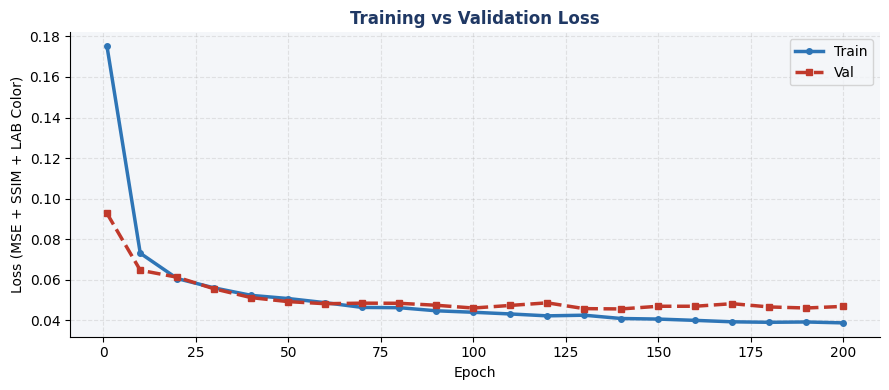

In [30]:
# ── Fig 1 — Loss Curves ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(EL, history['train_loss'], color=BLUE, lw=2.5, marker='o', ms=4, label='Train')
ax.plot(EL, history['val_loss'],   color=RED,  lw=2.5, marker='s', ms=4,
        linestyle='--', label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (MSE + SSIM + LAB Color)')
ax.set_title('Training vs Validation Loss', fontweight='bold', color=DARK)
ax.legend(); ax.grid(True, alpha=0.3, ls='--')
for sp in ['top','right']: ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.savefig('fig1_loss.png', dpi=150, bbox_inches='tight'); plt.show()

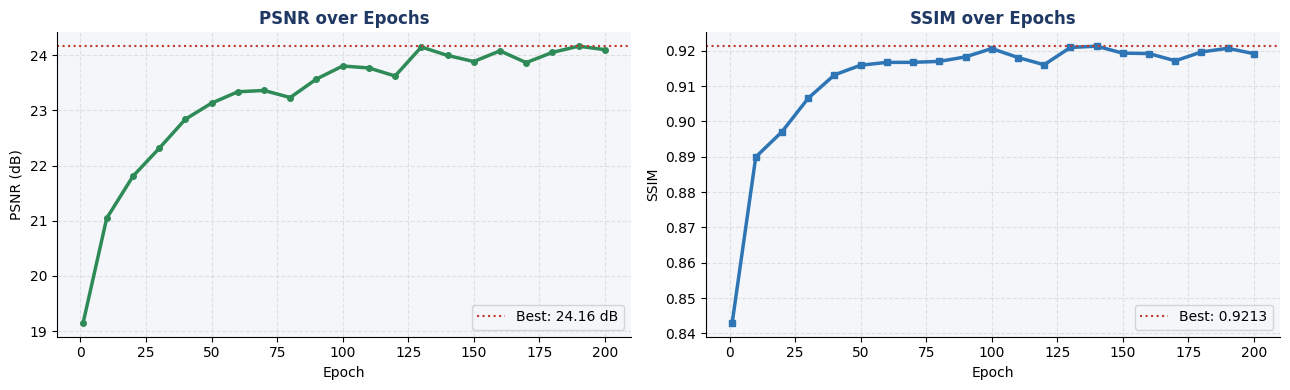

In [31]:
# ── Fig 2 — PSNR & SSIM over Epochs ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(EL, history['psnr'], color=GREEN, lw=2.5, marker='o', ms=4)
ax1.axhline(max(history['psnr']), color=RED, lw=1.5, ls=':',
            label=f"Best: {max(history['psnr']):.2f} dB")
ax1.set(xlabel='Epoch', ylabel='PSNR (dB)', title='PSNR over Epochs')
ax1.legend(); ax1.grid(True, alpha=0.3, ls='--')

ax2.plot(EL, history['ssim'], color=BLUE, lw=2.5, marker='s', ms=4)
ax2.axhline(max(history['ssim']), color=RED, lw=1.5, ls=':',
            label=f"Best: {max(history['ssim']):.4f}")
ax2.set(xlabel='Epoch', ylabel='SSIM', title='SSIM over Epochs')
ax2.legend(); ax2.grid(True, alpha=0.3, ls='--')

for ax in [ax1, ax2]:
    ax.set_title(ax.get_title(), fontweight='bold', color=DARK)
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.savefig('fig2_psnr_ssim.png', dpi=150, bbox_inches='tight'); plt.show()

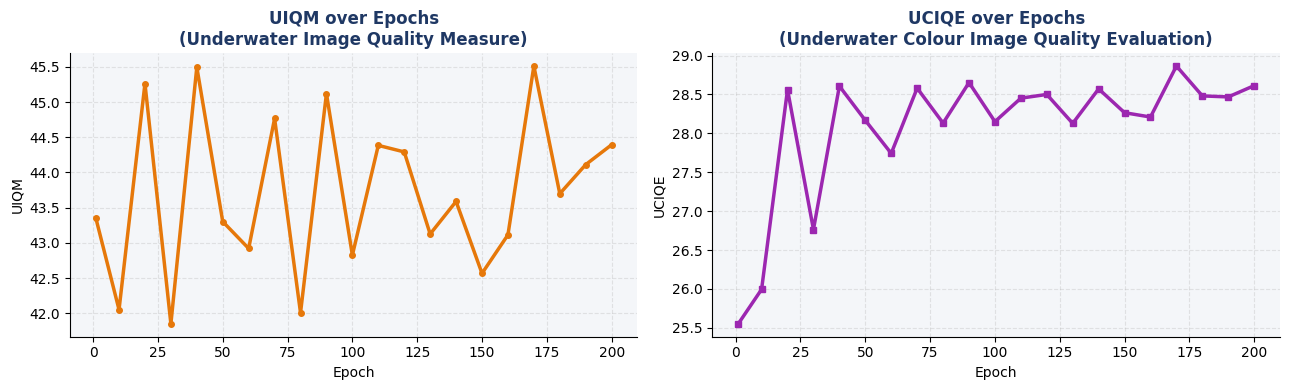

In [32]:
# ── Fig 3 — UIQM & UCIQE over Epochs ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(EL, history['uiqm'],  color=ORA, lw=2.5, marker='o', ms=4)
ax1.set(xlabel='Epoch', ylabel='UIQM',
        title='UIQM over Epochs\n(Underwater Image Quality Measure)')
ax1.grid(True, alpha=0.3, ls='--')

ax2.plot(EL, history['uciqe'], color=PUR, lw=2.5, marker='s', ms=4)
ax2.set(xlabel='Epoch', ylabel='UCIQE',
        title='UCIQE over Epochs\n(Underwater Colour Image Quality Evaluation)')
ax2.grid(True, alpha=0.3, ls='--')

for ax in [ax1, ax2]:
    ax.set_title(ax.get_title(), fontweight='bold', color=DARK)
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.savefig('fig3_uiqm_uciqe.png', dpi=150, bbox_inches='tight'); plt.show()

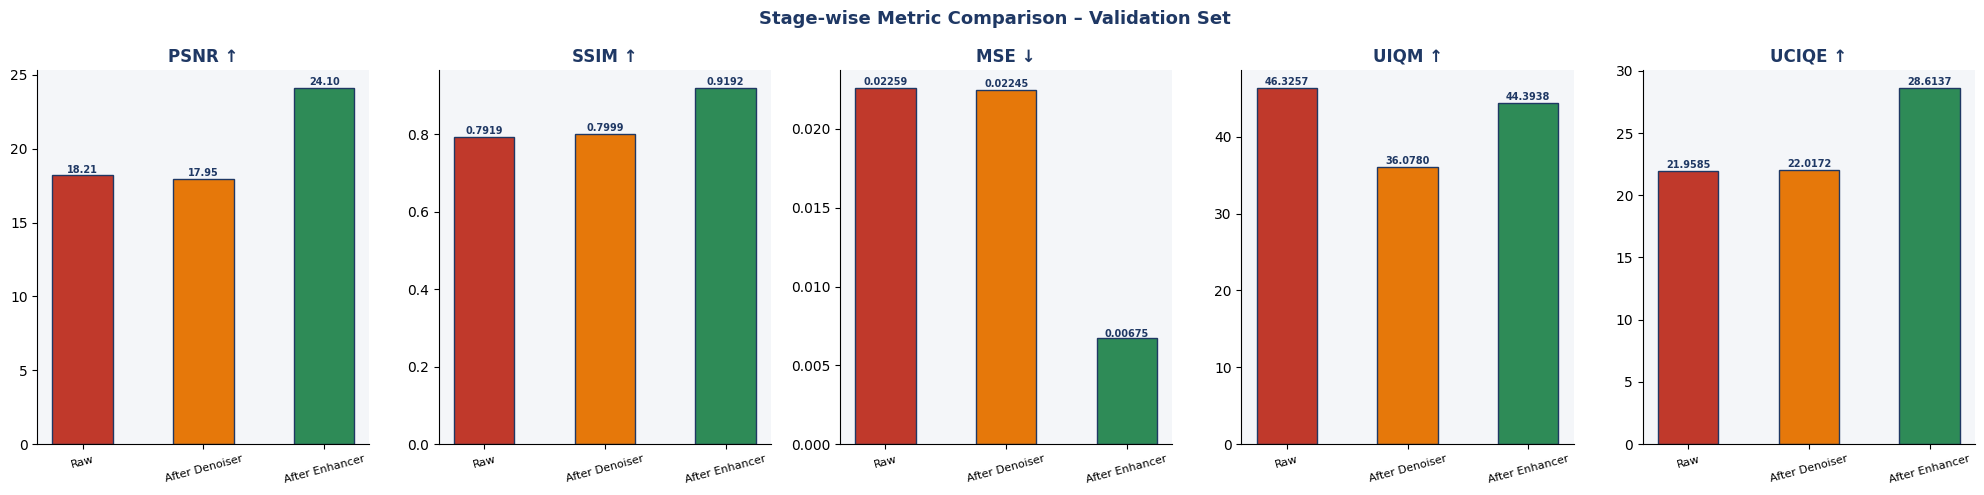

In [33]:
# ── Fig 4 — Stage-wise Metric Comparison ──────────────────────────────────────
denoiser.eval(); enhancer.eval()
raw_m = {k:[] for k in ['PSNR','SSIM','MSE','UIQM','UCIQE']}
den_m = {k:[] for k in ['PSNR','SSIM','MSE','UIQM','UCIQE']}
enh_m = {k:[] for k in ['PSNR','SSIM','MSE','UIQM','UCIQE']}

with torch.no_grad():
    for rb, refb in val_loader:
        rb, refb = rb.to(DEVICE), refb.to(DEVICE)
        db = denoiser(rb)
        eb = enhancer(db)
        for k, v in compute_all_metrics(rb,  refb).items(): raw_m[k].append(v)
        for k, v in compute_all_metrics(db,  refb).items(): den_m[k].append(v)
        for k, v in compute_all_metrics(eb,  refb).items(): enh_m[k].append(v)

metrics_list = ['PSNR','SSIM','MSE','UIQM','UCIQE']
arrows  = {'PSNR':'↑','SSIM':'↑','MSE':'↓','UIQM':'↑','UCIQE':'↑'}
stage_d = [raw_m, den_m, enh_m]
stage_l = ['Raw','After Denoiser','After Enhancer']
colors  = [RED, ORA, GREEN]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Stage-wise Metric Comparison – Validation Set',
             fontsize=13, fontweight='bold', color=DARK)

for ax, met in zip(axes, metrics_list):
    vals = [np.mean(d[met]) for d in stage_d]
    bars = ax.bar(stage_l, vals, color=colors, edgecolor=DARK, lw=1, width=0.5)
    ax.set_title(f'{met} {arrows[met]}', fontweight='bold', color=DARK)
    ax.tick_params(axis='x', labelsize=8, rotation=15)
    for bar, val in zip(bars, vals):
        fmt = '.2f' if met=='PSNR' else ('.5f' if met=='MSE' else '.4f')
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{val:{fmt}}', ha='center', fontsize=7, fontweight='bold', color=DARK)
    for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig('fig4_stagewise.png', dpi=150, bbox_inches='tight'); plt.show()

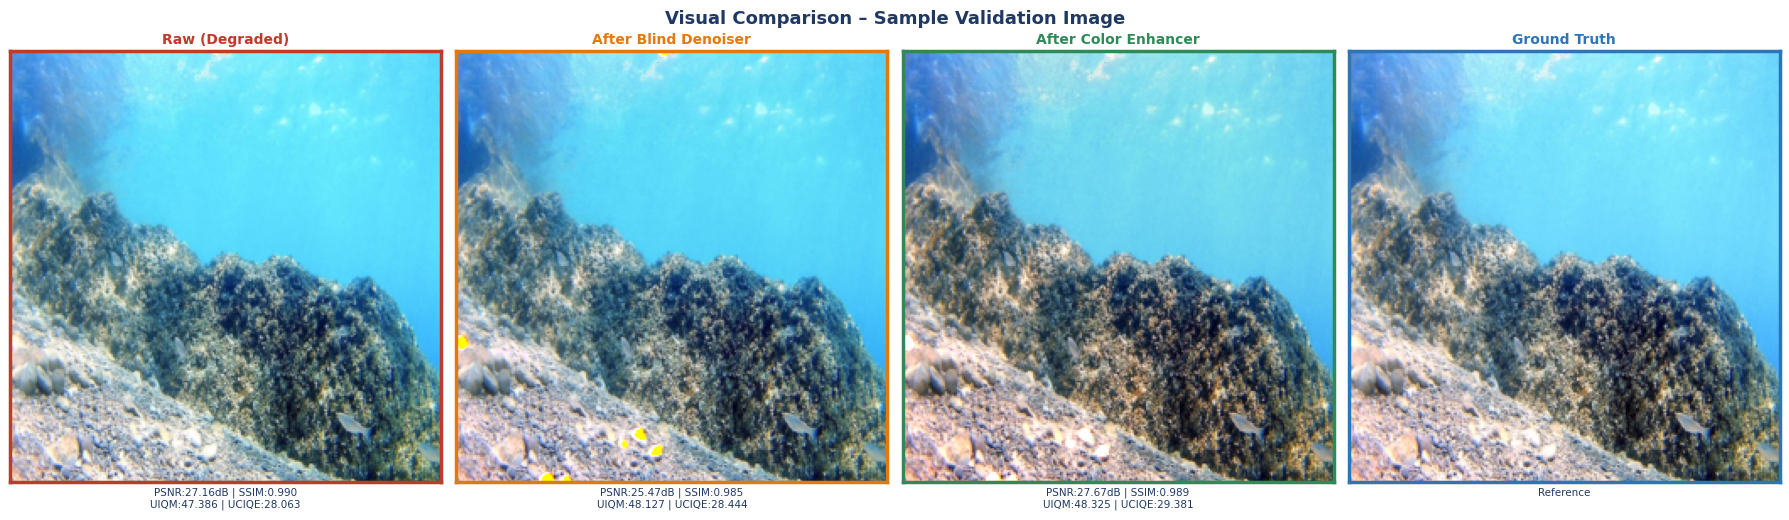

In [34]:
# ── Fig 5 — Visual Comparison ─────────────────────────────────────────────────
sample_raw, sample_ref = val_set[0]
sample_raw = sample_raw.unsqueeze(0).to(DEVICE)
sample_ref = sample_ref.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    sample_den = denoiser(sample_raw)
    sample_enh = enhancer(sample_den)

def fmt_sub(m):
    return (f"PSNR:{m['PSNR']:.2f}dB | SSIM:{m['SSIM']:.3f}\n"
            f"UIQM:{m['UIQM']:.3f} | UCIQE:{m['UCIQE']:.3f}")

panels = [
    (sample_raw, 'Raw (Degraded)',       RED,   fmt_sub(compute_all_metrics(sample_raw, sample_ref))),
    (sample_den, 'After Blind Denoiser', ORA,   fmt_sub(compute_all_metrics(sample_den, sample_ref))),
    (sample_enh, 'After Color Enhancer', GREEN, fmt_sub(compute_all_metrics(sample_enh, sample_ref))),
    (sample_ref, 'Ground Truth',         BLUE,  'Reference'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Visual Comparison – Sample Validation Image',
             fontsize=13, fontweight='bold', color=DARK)
for ax, (img_t, lbl, bc, sub) in zip(axes, panels):
    ax.imshow(t2np(img_t))
    ax.set_title(lbl, fontsize=10, fontweight='bold', color=bc, pad=5)
    ax.set_xlabel(sub, fontsize=7.5, color=DARK)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_edgecolor(bc); sp.set_linewidth(2.5); sp.set_visible(True)

plt.tight_layout()
plt.savefig('fig5_visual.png', dpi=150, bbox_inches='tight'); plt.show()

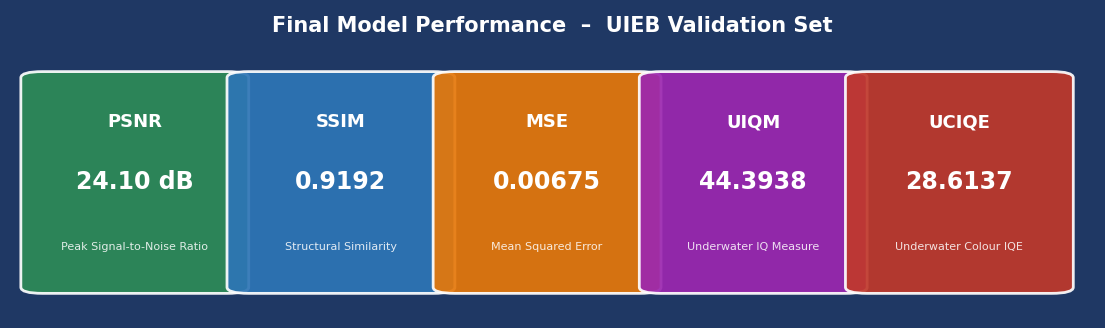


── Final Results ──────────────────────────────────────
  PSNR  : 24.1008
  SSIM  : 0.9192
  MSE   : 0.0067
  UIQM  : 44.3938
  UCIQE : 28.6137
  PSNR gain vs raw : +5.89 dB


In [35]:
# ── Fig 6 — Final Summary Card ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off'); fig.patch.set_facecolor(DARK)
ax.text(0.5, 0.93, 'Final Model Performance  –  UIEB Validation Set',
        transform=ax.transAxes, ha='center', fontsize=15,
        fontweight='bold', color='white')

final = {k: np.mean(enh_m[k]) for k in ['PSNR','SSIM','MSE','UIQM','UCIQE']}
cards = [
    ('PSNR',  f"{final['PSNR']:.2f} dB", GREEN, 'Peak Signal-to-Noise Ratio'),
    ('SSIM',  f"{final['SSIM']:.4f}",     BLUE,  'Structural Similarity'),
    ('MSE',   f"{final['MSE']:.5f}",      ORA,   'Mean Squared Error'),
    ('UIQM',  f"{final['UIQM']:.4f}",     PUR,   'Underwater IQ Measure'),
    ('UCIQE', f"{final['UCIQE']:.4f}",    RED,   'Underwater Colour IQE'),
]
for i, (met, val, col, sub) in enumerate(cards):
    x = 0.03 + i*0.19
    rect = FancyBboxPatch((x, 0.1), 0.17, 0.68, transform=ax.transAxes,
                          boxstyle='round,pad=0.02', facecolor=col,
                          edgecolor='white', lw=2, alpha=0.92, clip_on=False)
    ax.add_patch(rect)
    ax.text(x+0.085, 0.62, met,  transform=ax.transAxes, ha='center',
            fontsize=13, fontweight='bold', color='white')
    ax.text(x+0.085, 0.42, val,  transform=ax.transAxes, ha='center',
            fontsize=17, fontweight='bold', color='white')
    ax.text(x+0.085, 0.22, sub,  transform=ax.transAxes, ha='center',
            fontsize=8,  color='white', alpha=0.85)

plt.savefig('fig6_summary.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

print('\n── Final Results ──────────────────────────────────────')
for k in ['PSNR','SSIM','MSE','UIQM','UCIQE']:
    print(f'  {k:6s}: {final[k]:.4f}')
print(f'  PSNR gain vs raw : +{final["PSNR"] - np.mean(raw_m["PSNR"]):.2f} dB')